import libraries an load data

In [11]:
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
tsla = pd.read_csv(
    "../data/processed/TSLA.csv",
    index_col=0,
    parse_dates=True
)

tsla.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


the close price

In [12]:
tsla = tsla[["Close"]]

train/test split

In [13]:
tsla = tsla.sort_index()
train = tsla[tsla.index < "2025-01-01"]
test = tsla[tsla.index >= "2025-01-01"]

check sizes

In [14]:
print(train.shape)
print(test.shape)

(2516, 1)
(372, 1)


visualize the split

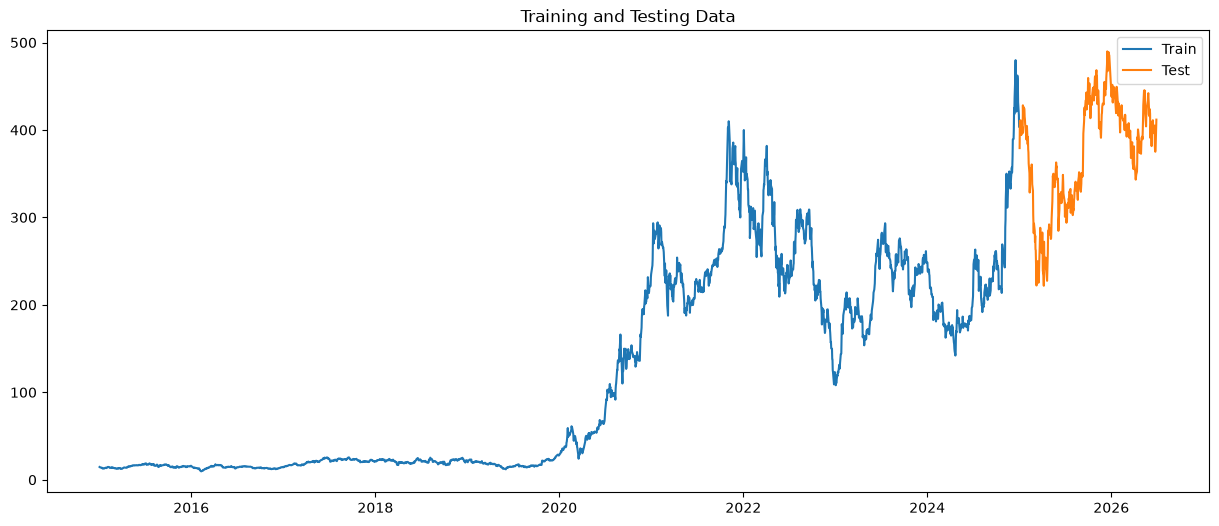

In [15]:
plt.figure(figsize=(15, 6))

plt.plot(train, label="Train")
plt.plot(test, label="Test")

plt.legend()
plt.title("Training and Testing Data")
plt.show()

In [16]:
auto_model = auto_arima(
    train["Close"],
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.71 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.34 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.474 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 07 Jul 2026   AIC                          16368.109
Time:                        18:26:13   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    

train ARIMA 

In [17]:
model = ARIMA(
    train["Close"],
    order=(0, 1, 0)
)

model_fit = model.fit()

In [18]:
forecast = model_fit.forecast(
    steps=len(test)
)

the plot

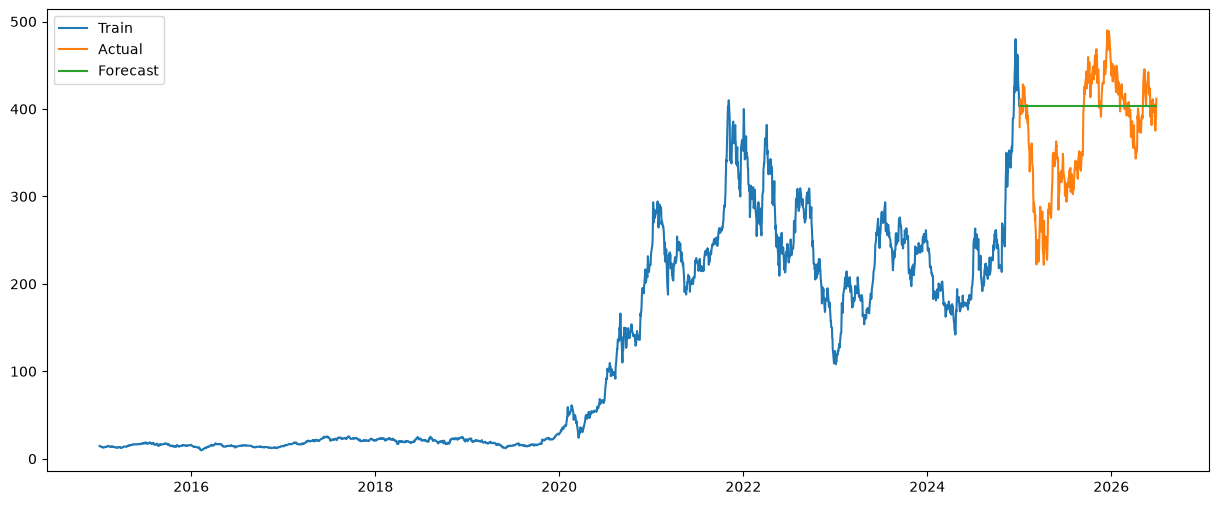

In [19]:
plt.figure(figsize=(15, 6))

plt.plot(train.index, train["Close"], label="Train")

plt.plot(test.index, test["Close"], label="Actual")

plt.plot(test.index, forecast, label="Forecast")

plt.legend()

plt.show()

evaluation

In [35]:
arima_mae = mean_absolute_error(test, forecast)

arima_rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

arima_mape = mean_absolute_percentage_error(
    test,
    forecast
)

print(arima_mae)
print(arima_rmse)
print(arima_mape)

54.44118233137233
70.53934610418263
0.17240653410477236


LTSM

import

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from sklearn.preprocessing import MinMaxScaler

scale the data

In [22]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(tsla[["Close"]])

create sequence

In [23]:
window_size = 60

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

reshape it

In [24]:
X = X.reshape((X.shape[0], X.shape[1], 1))

train/test split

In [25]:
train_size = len(train)

X_train = X[:train_size-window_size]
y_train = y[:train_size-window_size]

X_test = X[train_size-window_size:]
y_test = y[train_size-window_size:]

build LSTM

In [26]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=False,
        input_shape=(window_size, 1)
    )
)

model.add(Dense(1))

compile it

In [27]:
model.compile(
    optimizer="adam",
    loss="mse"
)

train it

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0095 - val_loss: 0.0025
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 8.6426e-04 - val_loss: 0.0023
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 8.1688e-04 - val_loss: 0.0021
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 7.7247e-04 - val_loss: 0.0019
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 6.7851e-04 - val_loss: 0.0019
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 6.0457e-04 - val_loss: 0.0017
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 5.3474e-04 - val_loss: 0.0018
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 5.1724e-04 - val_loss: 0.0014
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 4.6766e-04 - val_loss: 0.0029
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 4.4447e-04 - val_loss: 0.0017
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 4.2386e-04 - val_loss: 0.0013
Epoch 12/20
77/77 ━━━━━

predict

In [29]:
predictions = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


convert back to prices

In [30]:
predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

plot

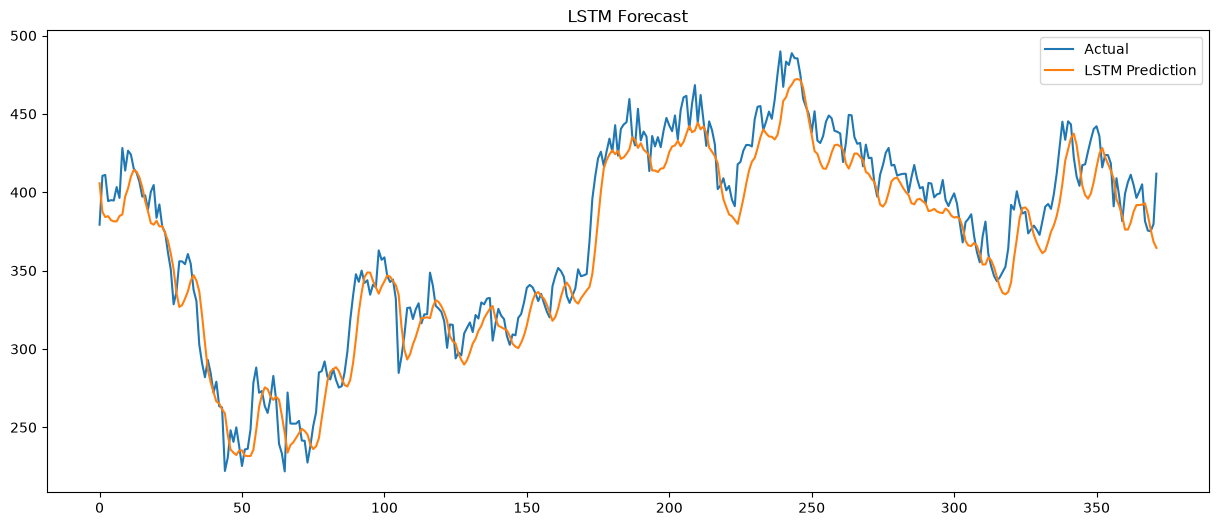

In [31]:
plt.figure(figsize=(15,6))

plt.plot(actual, label="Actual")

plt.plot(predictions, label="LSTM Prediction")

plt.legend()

plt.title("LSTM Forecast")

plt.show()

evaluate

In [37]:
lstm_mae = mean_absolute_error(actual, predictions)

lstm_rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

lstm_mape = mean_absolute_percentage_error(
    actual,
    predictions
)

print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)

MAE : 14.606957220262101
RMSE: 18.274263817529704
MAPE: 0.03986365062145061


compare with ARIMA

In [38]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "LSTM"],
    "MAE": [arima_mae, lstm_mae],
    "RMSE": [arima_rmse, lstm_rmse],
    "MAPE": [arima_mape, lstm_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,54.441182,70.539346,0.172407
1,LSTM,14.606957,18.274264,0.039864
